# Basic Data Indexing

In [1]:
import warnings
import pyearthtools.data

# Catch name override warning of ERA5 using site installation
with warnings.catch_warnings(action="ignore"):
    import site_archive_nci

## Variables

In [2]:
doi = '2022-04-01'
var = 'tmax'

## DataIndexes
One of the base classes of `pyearthtools.data` is the `DataIndex`, which provides a unified interface to accessing data, and common data retrieval techniques.

As of the writing of this notebook, the following data sources have been implemented:
- ERA5
- ACCESS G/C
- BRAN
- OceanMAPS
- Himiwari 8/9

Each of these sources requires it's own initalisation parameters such that when attempting to retrieve data, only the timestep is needed.

This Notebook shall show the features available with examples with the ERA5 dataset

In [3]:
era5 = pyearthtools.data.archive.ERA5(var,)

In [4]:
era5

ERA5
	Description                    ECWMF ReAnalysis v5
		 range                          '1970-current'
		 Documentation                  'https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation'


	Initialisation                 
		 level_value                    None
		 product                        'reanalysis'
		 variables                      ['tmax']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Rename                         {'names': {'t2m': "'2t'", 'u10': "'10u'", 'v10': "'10v'", 'siconc': "'ci'"}}

## Data Loading
Using the `search` function allows retrieval of the filepaths to each requested variable at a given time.

From this, the data can be automatically loaded simply by calling the DataIndex with a date, which provides a couple of useful features, which will be explored in later notebooks. 

In [5]:
era5.search(doi)

[{'tmax': PosixPath('/g/data/rt52/era5/single-levels/reanalysis/tmax/2022/tmax_era5_wave_sfc_20220401-20220430.nc')}]

In [6]:
era5_ds = era5(doi)

In [7]:
era5_ds

<xarray.Dataset> Size: 50MB
Dimensions:    (longitude: 720, latitude: 361, time: 24)
Coordinates:
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * time       (time) datetime64[ns] 192B 2022-04-01 ... 2022-04-01T23:00:00
Data variables:
    tmax       (time, latitude, longitude) float64 50MB dask.array<chunksize=(24, 182, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2022-08-01 09:25:07 UTC+1000 by era5_replication_tools-1.10...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis period_corresponding_to_maxim...

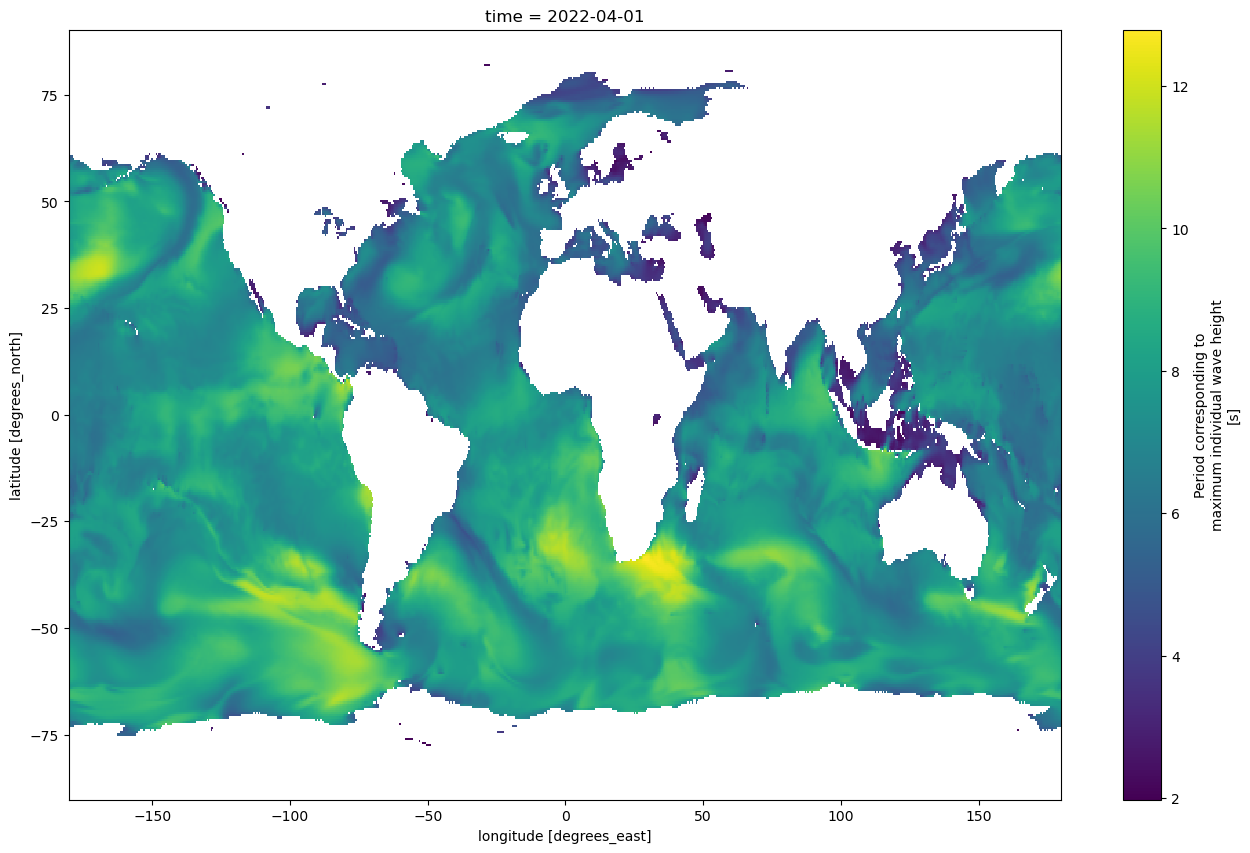

In [8]:
era5_ds[var][0].plot(figsize = (16,10))